In [1]:
import pandas as pd
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from category_encoders import TargetEncoder

In [2]:

RAW_MERGED   = "../../data/merged_data/merged.parquet"   # NB1 output
DATA_DIR     = "../../data/merged_data/"
ARTIFACT_DIR = "../../artifacts/"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

RANDOM_SEED = 42   

#load dataset
df = pd.read_parquet(RAW_MERGED)
print("Loaded:", df.shape)
df.head()

Loaded: (250001, 18)


,job_title,experience_years,education_level,skills_count,industry,company_size,country,remote_work,certifications,salary,rank,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,outlier_flags
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,109413,118.0,21.2,5.6,13.7,23.8,15.1,82.6,False
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,93764,10.0,70.2,33.4,52.5,77.3,62.5,127.4,False
2,Frontend Developer,18.0,PhD,4.0,Media,Medium,Singapore,No,1.0,148123,4.0,76.7,67.2,72.1,74.6,50.4,111.1,False
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,189123,12.0,64.8,33.2,49.6,71.2,61.7,103.7,False
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,165069,25.0,59.3,20.9,40.9,60.8,54.7,122.6,False


In [3]:
print ("Rows Dropped:", len(df))
df= df.dropna(subset=["cost_of_living_index"])
df['country_name'] = df['country']   # preserve original string before TargetEncoder overwrites it
print("Rows Remaining:", len(df))

Rows Dropped: 250001
Rows Remaining: 224935


In [4]:

# How over/underpaid someone is relative to their job title mean
job_mean = df.groupby("job_title")["salary"].transform("mean")
df["salary_to_mean_ratio"] = df["salary"] / job_mean

# Earnings efficiency — salary per year of experience
df["salary_per_year_experience"] = df["salary"] / (df["experience_years"] + 1)

# Deviation from country average salary
country_mean = df.groupby("country")["salary"].transform("mean")
df["salary_vs_country_mean"] = df["salary"] - country_mean


# Proportion of salary consumed by rent
df["rent_burden"] = df["rent_index"] / (df["salary"] )

# Proportion of salary consumed by groceries
df["grocery_burden"] = df["groceries_index"] / (df["salary"] )


DEVELOPING_THRESHOLD = 100
df["developing_country_flag"] = (
    df["local_purchasing_power_index"] < DEVELOPING_THRESHOLD
).astype(int)


print(df[["salary_to_mean_ratio", "salary_per_year_experience", 
          "salary_vs_country_mean", "rent_burden", 
          "grocery_burden", "developing_country_flag"]].describe())

print("\nDeveloping country flag distribution:")
print(df["developing_country_flag"].value_counts())

print("\nCountries flagged as developing:")
print(df[df["developing_country_flag"] == 1]["country"].unique()) # Note: Only India falls below the LPP threshold of 100 in this dataset, :)
#please note that the developing country flag is based on the local purchasing power index, which is a measure of the relative cost of living and 
#  the purchasing power of income in different countries. In this dataset, only India falls below the threshold of 100, which is why it is flagged as a developing country.
# (thisis also a fake dataset so it is a reflection of the reall world )


       salary_to_mean_ratio  salary_per_year_experience  \
count         224935.000000               224935.000000   
mean               1.000000                22925.719504   
std                0.240269                26353.999527   
min                0.264606                 3221.631579   
25%                0.832972                 9704.972222   
50%                0.987216                13406.555556   
75%                1.153599                23103.975000   
max                2.148387               244037.000000   

       salary_vs_country_mean    rent_burden  grocery_burden  \
count            2.249350e+05  224935.000000   224935.000000   
mean            -5.548146e-12       0.000227        0.000441   
std              3.096149e+04       0.000127        0.000135   
min             -1.079393e+05       0.000029        0.000123   
25%             -2.130392e+04       0.000156        0.000350   
50%             -1.685814e+03       0.000204        0.000427   
75%              1.9

In [5]:
# Feature Engineering

# Divide raw salary by the Cost-of-Living Plus Rent Index
# so that salaries across countries reflect real purchasing power.
df["col_adjusted_salary"] = df["salary"] / (df["cost_of_living_plus_rent_index"] / 100)

# Purchasing Power Parity index
df["ppp_index"] = df["local_purchasing_power_index"]

#Experience brackets 
bins   = [-1, 2, 5, 10, 15, 20]
labels = ["0-2", "3-5", "6-10", "11-15", "16-20"]
df["experience_bracket"] = pd.cut(df["experience_years"], bins=bins, labels=labels)

# Salary-to-rent ratio 
df["salary_rent_ratio"] = df["salary"] / (df["rent_index"] + 1e-6)

print(" features added:")
print(df[["col_adjusted_salary","ppp_index","experience_bracket","salary_rent_ratio"]].describe())

 features added:
       col_adjusted_salary      ppp_index  salary_rent_ratio
count         2.249350e+05  224935.000000      224935.000000
mean          3.491439e+05     116.670942        6143.567281
std           1.580189e+05      15.795611        4467.491310
min           7.321359e+04      82.600000         785.520822
25%           2.534707e+05     111.100000        3802.507916
50%           3.150318e+05     120.200000        4906.746122
75%           3.867583e+05     124.900000        6413.922623
max           1.410715e+06     142.300000       34512.136694


In [6]:

#Ordinal features 
EDU_ORDER        = ["High School", "Diploma", "Bachelor", "Master", "PhD"]
COMPANY_ORDER    = ["Small", "Medium", "Large", "Enterprise"]
REMOTE_ORDER     = ["No", "Hybrid", "Yes"]
EXPERIENCE_ORDER = ["0-2", "3-5", "6-10", "11-15", "16-20"]

ordinal_cols = {
    "education_level"   : EDU_ORDER,
    "company_size"      : COMPANY_ORDER,
    "remote_work"       : REMOTE_ORDER,
    "experience_bracket": EXPERIENCE_ORDER,
}

ord_encoder = OrdinalEncoder(
    categories=[v for v in ordinal_cols.values()],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

df[list(ordinal_cols.keys())] = ord_encoder.fit_transform(df[list(ordinal_cols.keys())])

# Replaces each category with its mean salary, 
HIGH_CARD_COLS = ["job_title", "industry", "country"]

target_encoder = TargetEncoder(cols=HIGH_CARD_COLS, smoothing=10)
df[HIGH_CARD_COLS] = target_encoder.fit_transform(df[HIGH_CARD_COLS], df["salary"])

print("Encoding complete. Sample:")
df[HIGH_CARD_COLS + ["salary"]].head()

Encoding complete. Sample:


,job_title,industry,country,salary
0,174370.436341,146430.311344,97690.402249,109413
1,120432.104074,146710.888128,139362.150804,93764
2,133243.850220,146588.405345,139340.696625,148123
3,123146.825910,146131.552366,167391.273396,189123
4,158317.316628,146185.798757,139440.637291,165069


In [7]:
#Select final feature set & define target

DROP_COLS = [
    "rank",                         
    "outlier_flags",                # not a predictor
]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

LEAK_COLS = [    # Remove target leakage features
    "salary_to_mean_ratio",
    "salary_per_year_experience",
    "salary_vs_country_mean",
    "rent_burden",
    "grocery_burden",
    "col_adjusted_salary",
    "salary_rent_ratio"
]

TARGET  = "salary"
FEATURES = [c for c in df.columns if c not in [TARGET, "country_name"] + LEAK_COLS]

print("\nFeatures :" , len(FEATURES), FEATURES)
print("Target:", TARGET)


Features : 18 ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'country', 'remote_work', 'certifications', 'cost_of_living_index', 'rent_index', 'cost_of_living_plus_rent_index', 'groceries_index', 'restaurant_price_index', 'local_purchasing_power_index', 'developing_country_flag', 'ppp_index', 'experience_bracket']
Target: salary


In [8]:
# Normalize / Standardize Numeric Columns
NUMERIC_COLS = df[FEATURES].select_dtypes(include="number").columns.tolist()

scaler = StandardScaler()
df[NUMERIC_COLS] = scaler.fit_transform(df[NUMERIC_COLS])

print("Scaled" , len(NUMERIC_COLS), "numeric columns with StandardScaler.")
print("Scaler mean (first 5):", scaler.mean_[:5])

Scaled 18 numeric columns with StandardScaler.
Scaler mean (first 5): [1.46417379e+05 1.00069709e+01 1.99998222e+00 9.99941761e+00
 1.46417379e+05]


In [9]:
# 7. Train / Val / Test Split 
X = df[FEATURES]
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED
)

print("Train :", X_train.shape, " |  Val :", X_val.shape, " |  Test :", X_test.shape)

# Re-attach target for export
train_df = X_train.copy(); train_df[TARGET] = y_train
val_df   = X_val.copy();   val_df[TARGET]   = y_val
test_df  = X_test.copy();  test_df[TARGET]  = y_test

# Re-attach original country name (for anomaly detection in NB05)
test_df['country_name']  = df.loc[X_test.index,  'country_name'].values

Train : (157454, 18)  |  Val : (33740, 18)  |  Test : (33741, 18)


In [10]:
#Export Parquet splits
train_df.to_parquet(f"{DATA_DIR}train.parquet", index=False)
val_df  .to_parquet(f"{DATA_DIR}val.parquet",   index=False)
test_df .to_parquet(f"{DATA_DIR}test.parquet",  index=False)

print("Exported: train.parquet, val.parquet, test.parquet")

Exported: train.parquet, val.parquet, test.parquet


In [11]:
# NB3 / NB4
# Save artifacts for NB3 / NB4
joblib.dump(scaler, f"{ARTIFACT_DIR}scaler.pkl")
joblib.dump({"ordinal": ord_encoder, "target": target_encoder}, f"{ARTIFACT_DIR}encoder.pkl")
print("Artifacts saved: scaler.pkl, encoder.pkl")

Artifacts saved: scaler.pkl, encoder.pkl


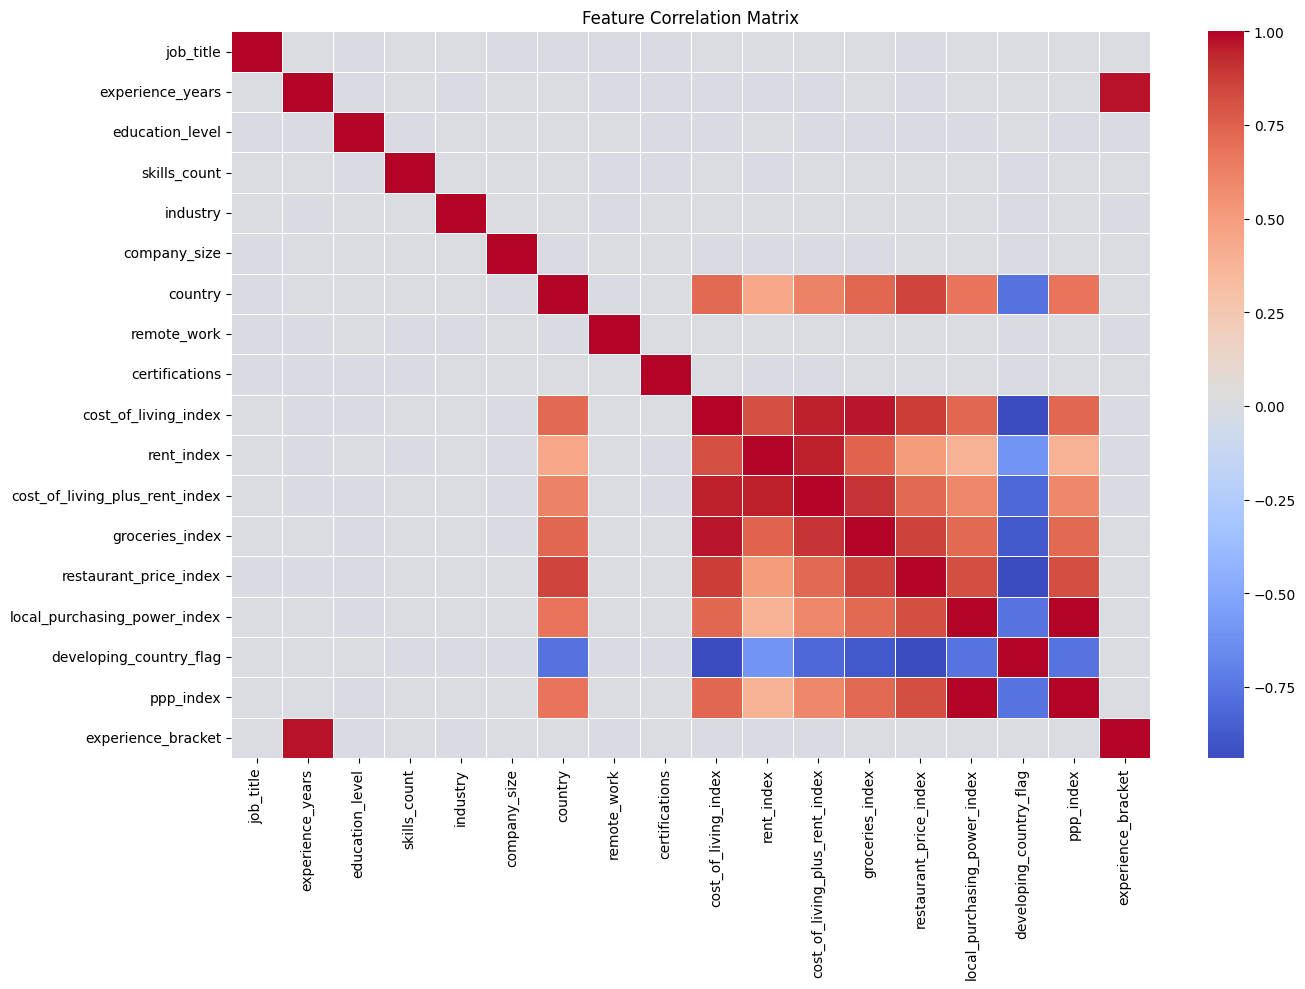

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(
    df[FEATURES].corr(),
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

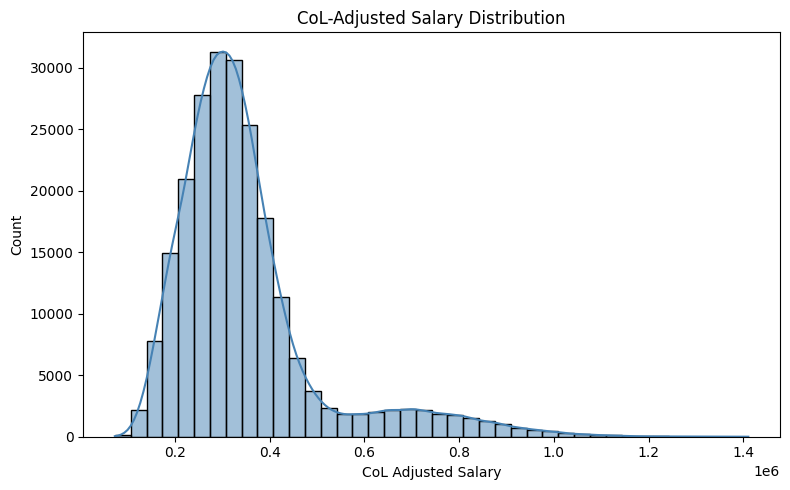

In [13]:
# CoL Adjusted Salary Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["col_adjusted_salary"], bins=40, kde=True, color="steelblue")
plt.title("CoL-Adjusted Salary Distribution")
plt.xlabel("CoL Adjusted Salary")
plt.tight_layout()
plt.show()

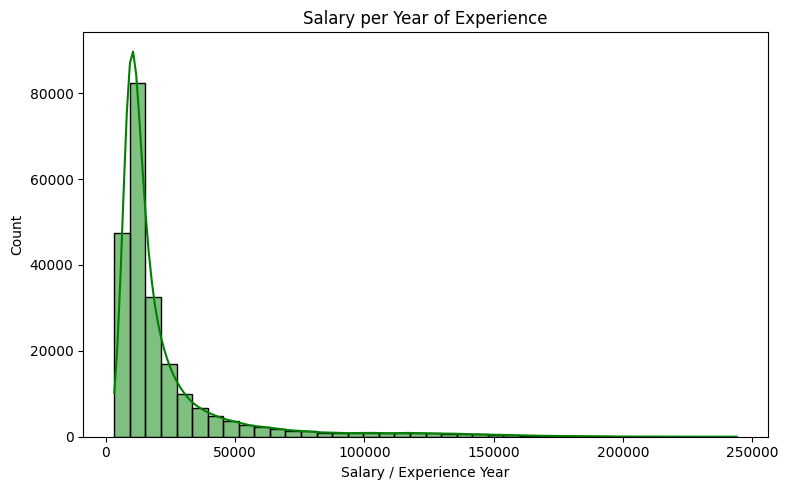

In [14]:
# Salary per Year of Experience
plt.figure(figsize=(8, 5))
sns.histplot(df["salary_per_year_experience"], bins=40, kde=True, color="green")
plt.title("Salary per Year of Experience")
plt.xlabel("Salary / Experience Year")
plt.tight_layout()
plt.show()

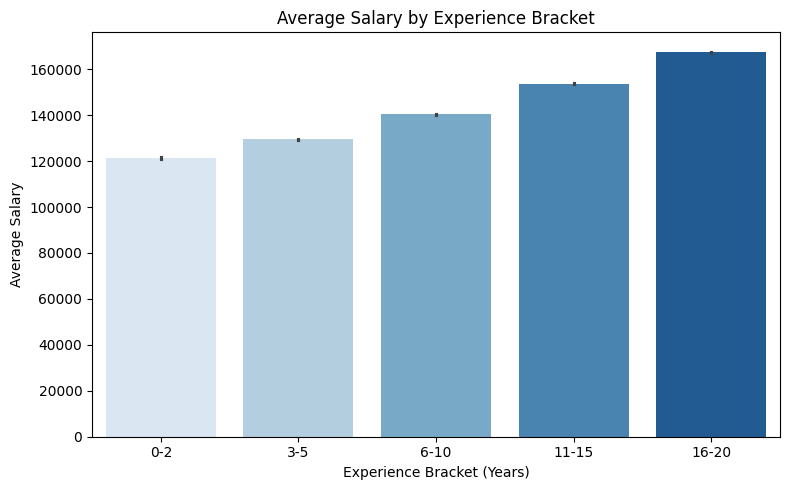

In [15]:
# Experience Bracket vs Salary
plt.figure(figsize=(8, 5))
sns.barplot(
    data=pd.read_parquet(RAW_MERGED).assign(
        experience_bracket=lambda x: pd.cut(
            x["experience_years"],
            bins=[-1, 2, 5, 10, 15, 20],
            labels=["0-2", "3-5", "6-10", "11-15", "16-20"]
        )
    ),
    x="experience_bracket",
    y="salary",
    hue="experience_bracket",
    legend=False,
    palette="Blues"
)
plt.title("Average Salary by Experience Bracket")
plt.xlabel("Experience Bracket (Years)")
plt.ylabel("Average Salary")
plt.tight_layout()
plt.show()

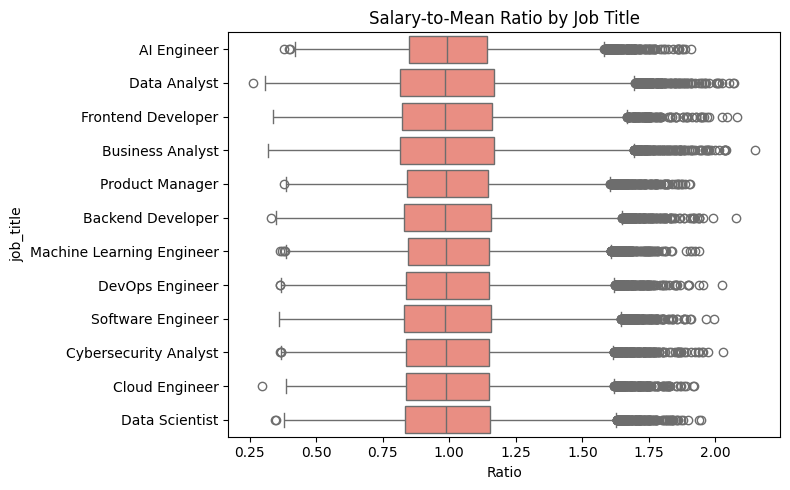

In [16]:
# Salary to Mean Ratio by Job Title
raw = pd.read_parquet(RAW_MERGED).dropna(subset=["cost_of_living_index"])
job_mean = raw.groupby("job_title")["salary"].transform("mean")
raw["salary_to_mean_ratio"] = raw["salary"] / job_mean

plt.figure(figsize=(8, 5))
sns.boxplot(data=raw, x="salary_to_mean_ratio", y="job_title", color="salmon")
plt.title("Salary-to-Mean Ratio by Job Title")
plt.xlabel("Ratio")
plt.tight_layout()
plt.show()